In [ ]:
from sklearn.model_selection    import train_test_split
from xgboost                    import XGBRegressor
from sklearn.metrics            import mean_absolute_error, r2_score

import pandas as pd
import numpy as np
import optuna

path = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\processed\churn_feature_data.csv"
df = pd.read_csv(path)

X = df.drop(columns=["CustomerID", "Churn", "FutureLTV_12M", "TotalCharges", "MonthlyCharges", "log_FutureLTV_12M"])
y = df["log_FutureLTV_12M"]

# Condificación One-Hot para variables categóricas y (False) mantener la explicabilidad
X = pd.get_dummies(X, drop_first=False)

# Estratificación de cuartiles
y_bins = pd.qcut(x=y, q=4, labels=False, duplicates="drop")

# Split del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_bins)

# Función de búsqueda para Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = XGBRegressor(**params).fit(X_train, y_train)
    
    # Predecir y calcular MAE en dólares reales
    y_pred_log = model.predict(X_test)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    return mae

# Se ejecuta la optimización
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Resultados
print(f"Mejor MAE en dólares: ${study.best_value:.2f}")
print("Mejores Parámetros encontrados:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")

Mejor MAE en dólares: $126.37
Mejores Parámetros encontrados:
 - n_estimators: 248
 - max_depth: 7
 - learning_rate: 0.03719877809573533
 - subsample: 0.9764701357170729
 - colsample_bytree: 0.9761492340963174
 - reg_alpha: 3.064032546874566
 - reg_lambda: 1.0553419171698797


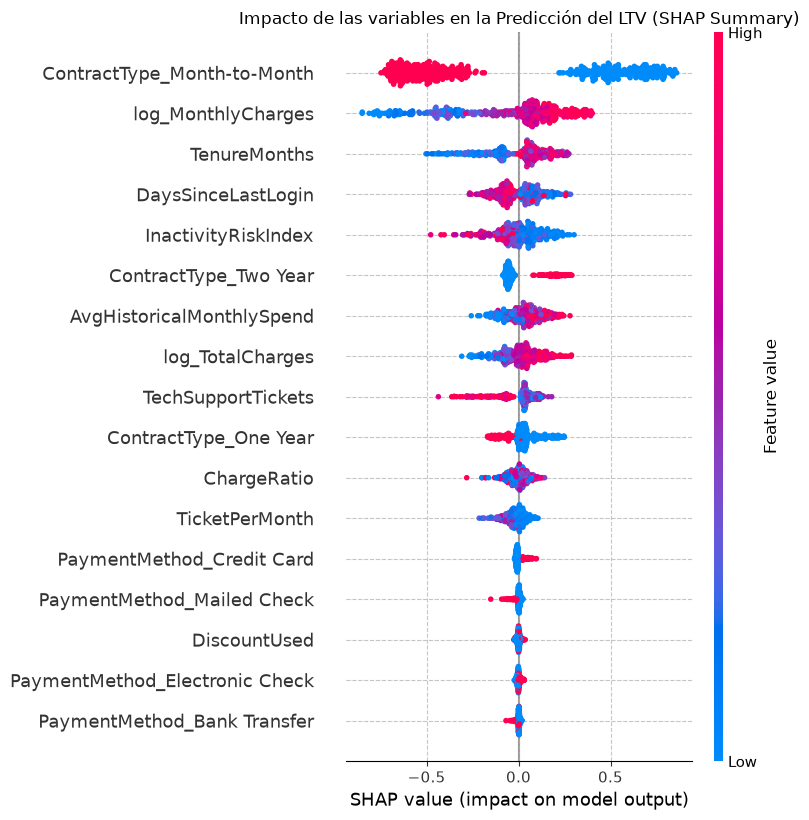

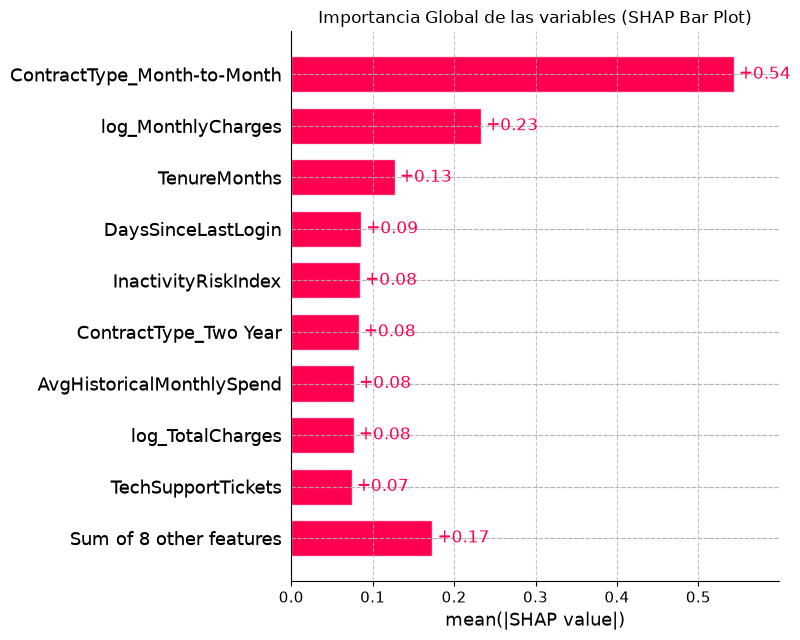

In [2]:
""" Gráficos de SHAP (Regresión LTV) """
import shap
import matplotlib.pyplot as plt

final_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1).fit(X_train, y_train)

# Crear el explicador de SHAP basado en árboles
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# Visualización 1: SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Impacto de las variables en la Predicción del LTV (SHAP Summary)")
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Visualización 2: SHAP Bar - Feature Importance
plt.figure(figsize=(12,6))
shap.plots.bar(shap_values, show=False)
plt.title("Importancia Global de las variables (SHAP Bar Plot)")
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()